 Implement Uniform Cost Search (UCS) traversal for the given graph starting from node 'A'.

UCS Traversal (List): ['A', 'B', 'D', 'C', 'F', 'E']
UCS Traversal (Path): A -> B -> D -> C -> F -> E

   Node  Cost
0    A     0
1    B     1
2    D     3
3    C     4
4    F     5
5    E     6


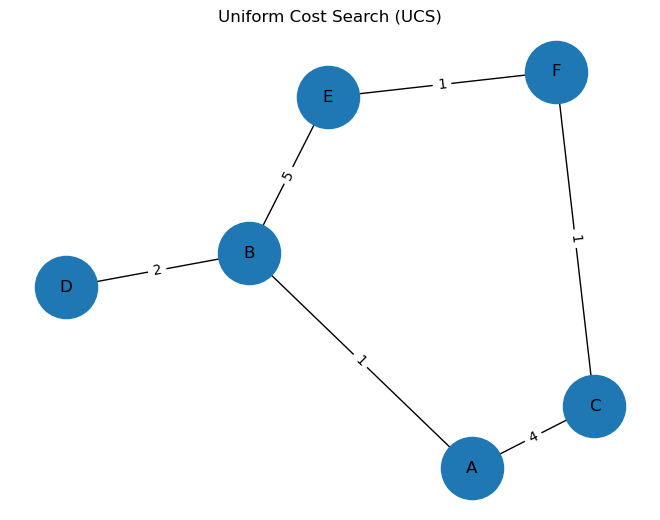

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import heapq


print(" Implement Uniform Cost Search (UCS) traversal for the given graph starting from node 'A'.")


graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('F', 1)],
    'F': []
}


def uniform_cost_search(g, start):
    visited = []
    pq = [(0, start)]   
    path_cost = {}

    while pq:
        cost, node = heapq.heappop(pq)

        if node not in visited:
            visited.append(node)
            path_cost[node] = cost

            for neighbor, weight in g[node]:
                heapq.heappush(pq, (cost + weight, neighbor))

    return visited, path_cost


result, costs = uniform_cost_search(graph, 'A')


arrow_path = " -> ".join(result)

print("\nUCS Traversal (List):", result)
print("UCS Traversal (Path):", arrow_path)


df = pd.DataFrame({
    "Node": result,
    "Cost": [costs[node] for node in result]
})

print("\n", df)


G = nx.Graph()


for u in graph:
    for v, w in graph[u]:
        G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)

labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Uniform Cost Search (UCS)")
plt.show()